In [1]:
# --- MASTER DATA REFRESH ---
# This block re-runs the pipeline to ensure OP_CARRIER is present in fused_df
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import time

# --- Library Setup ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import xgboost as xgb
print("🔄 REFRESHING DATA PIPELINE...")

# 1. SETUP: Ensure OP_CARRIER is requested
FLIGHT_COLS = ['FL_DATE', 'ORIGIN', 'DEST', 'DEP_TIME', 'DEP_DELAY', 'CANCELLED', 'DISTANCE', 'OP_CARRIER'] 
WEATHER_COLS = ['DATE', 'TMP', 'WND', 'VIS', 'AA1', 'SLP']
TARGET_AIRPORTS = ['ORD', 'DFW', 'MSP', 'DSM', 'MCI', 'ROC', 'TUL']

# 2. LOAD: Raw Flights (Cell 1 Logic)
print("   -> Reloading Flight Data (with Airlines)...")
flight_files = glob.glob("months/*.csv")
dfs = []
for f in flight_files:
    try:
        # Safe Load
        header = pd.read_csv(f, nrows=0).columns.tolist()
        use_cols = list(set(FLIGHT_COLS).intersection(header))
        dfs.append(pd.read_csv(f, usecols=use_cols))
    except: pass
flights = pd.concat(dfs, ignore_index=True)
flights = flights[flights['ORIGIN'].isin(TARGET_AIRPORTS)]
flights = flights[(flights['CANCELLED'] == 0) & (flights['DEP_TIME'].notna())]

# Time Fix
flights['date_temp'] = flights['FL_DATE'].astype(str).str.split(' ').str[0]
flights['date_clean'] = pd.to_datetime(flights['date_temp']).dt.strftime('%Y-%m-%d')
flights['dep_str'] = flights['DEP_TIME'].astype(int).astype(str).str.zfill(4)
flights.loc[flights['dep_str'] == '2400', 'dep_str'] = '0000'
flights['full_dep_time'] = pd.to_datetime(flights['date_clean'] + ' ' + flights['dep_str'], format='%Y-%m-%d %H%M')
flights['SCH_DEP_TIME'] = flights['full_dep_time'] - pd.to_timedelta(flights['DEP_DELAY'], unit='m')

# 3. MERGE: Weather (Cell 3 Logic)
print("   -> Re-Merging Weather Data...")
# Re-use the existing 'weather' dataframe if available to save time, otherwise reload
if 'weather' not in locals():
    # Quick weather reload if needed
    weather_files = glob.glob("weather/*.csv")
    w_dfs = []
    for f in weather_files:
        name = os.path.basename(f).lower()
        if 'chicago' in name: code = 'ORD'
        elif 'dallas' in name: code = 'DFW'
        elif 'minneapolis' in name: code = 'MSP'
        elif 'des_weather' in name: code = 'DSM'
        elif 'kansas' in name: code = 'MCI'
        elif 'rochester' in name: code = 'ROC'
        elif 'tulsa' in name: code = 'TUL'
        else: continue
        df = pd.read_csv(f, usecols=WEATHER_COLS, low_memory=False)
        df['airport_code'] = code
        tmp = df['TMP'].astype(str).str.split(',', expand=True)[0]
        df['temp_f'] = (pd.to_numeric(tmp, errors='coerce') / 10.0) * (9/5) + 32
        wnd = df['WND'].astype(str).str.split(',', expand=True)[3]
        df['wind_mph'] = (pd.to_numeric(wnd, errors='coerce') / 10.0) * 2.23694
        vis = df['VIS'].astype(str).str.split(',', expand=True)[0]
        df['vis_miles'] = pd.to_numeric(vis, errors='coerce') / 1609.34
        if 'AA1' in df.columns:
            prcp = df['AA1'].astype(str).str.split(',', expand=True)[1]
            df['precip_in'] = (pd.to_numeric(prcp, errors='coerce').fillna(0) * 0.03937)
        else: df['precip_in'] = 0.0
        df['merge_time'] = pd.to_datetime(df['DATE']).dt.floor('h')
        hourly = df.groupby(['airport_code', 'merge_time'])[['temp_f', 'wind_mph', 'vis_miles', 'precip_in']].mean().reset_index()
        w_dfs.append(hourly)
    weather = pd.concat(w_dfs, ignore_index=True).sort_values('merge_time')

# Execute Merge
flights = flights.sort_values('SCH_DEP_TIME')
fused_df = pd.merge_asof(
    flights, weather,
    left_on='SCH_DEP_TIME', right_on='merge_time',
    left_by='ORIGIN', right_by='airport_code',
    direction='backward', tolerance=pd.Timedelta('2h')
).dropna(subset=['temp_f'])

# 4. FEATURES: Re-engineer (Cell 4 Logic)
print("   -> Re-Calculating Features...")
fused_df['sch_hour'] = fused_df['SCH_DEP_TIME'].dt.hour
fused_df['sch_month'] = fused_df['SCH_DEP_TIME'].dt.month
fused_df['SCH_HOUR_SIN'] = np.sin(2 * np.pi * fused_df['sch_hour'] / 24)
fused_df['SCH_HOUR_COS'] = np.cos(2 * np.pi * fused_df['sch_hour'] / 24)
fused_df['SCH_MONTH_SIN'] = np.sin(2 * np.pi * fused_df['sch_month'] / 12)
fused_df['SCH_MONTH_COS'] = np.cos(2 * np.pi * fused_df['sch_month'] / 12)
fused_df['sch_hour_key'] = fused_df['SCH_DEP_TIME'].dt.floor('h')
fused_df['TRAFFIC_COUNT'] = fused_df.groupby(['ORIGIN', 'sch_hour_key'])['SCH_DEP_TIME'].transform('count')
fused_df['DEST_TRAFFIC'] = fused_df.groupby(['DEST', 'sch_hour_key'])['SCH_DEP_TIME'].transform('count')
fused_df['DEP_DELAY_LOG'] = np.log1p(np.maximum(0, fused_df['DEP_DELAY']))

print(f"✅ DATA REFRESH COMPLETE. Fused Data Shape: {fused_df.shape}")
print(f"   Column 'OP_CARRIER' exists: {'OP_CARRIER' in fused_df.columns}")

🔄 REFRESHING DATA PIPELINE...
   -> Reloading Flight Data (with Airlines)...
   -> Re-Merging Weather Data...
   -> Re-Calculating Features...
✅ DATA REFRESH COMPLETE. Fused Data Shape: (724611, 27)
   Column 'OP_CARRIER' exists: False


In [2]:
# CODE BLOCK 3: Weather Processing & Fusion (FIXED)
def process_and_merge_weather(flights):
    print("\n☁️ Processing NOAA Weather Data (with Trends)...")
    weather_files = glob.glob("weather/*.csv")
    dfs = []
    
    for f in weather_files:
        name = os.path.basename(f).lower()
        if 'chicago' in name: code = 'ORD'
        elif 'dallas' in name: code = 'DFW'
        elif 'minneapolis' in name: code = 'MSP'
        elif 'des_weather' in name: code = 'DSM'
        elif 'kansas' in name: code = 'MCI'
        elif 'rochester' in name: code = 'ROC'
        elif 'tulsa' in name: code = 'TUL'
        else: continue
            
        # Load with SLP
        df = pd.read_csv(f, usecols=WEATHER_COLS, low_memory=False)
        df['airport_code'] = code
        
        # 1. Standard Parsing
        tmp = df['TMP'].astype(str).str.split(',', expand=True)[0]
        df['temp_f'] = (pd.to_numeric(tmp, errors='coerce') / 10.0) * (9/5) + 32
        
        wnd = df['WND'].astype(str).str.split(',', expand=True)[3]
        df['wind_mph'] = (pd.to_numeric(wnd, errors='coerce') / 10.0) * 2.23694
        
        vis = df['VIS'].astype(str).str.split(',', expand=True)[0]
        df['vis_miles'] = pd.to_numeric(vis, errors='coerce') / 1609.34
        
        # Pressure (SLP)
        if 'SLP' in df.columns:
            slp = df['SLP'].astype(str).str.split(',', expand=True)[0]
            df['pressure'] = pd.to_numeric(slp, errors='coerce') / 10.0
        else: df['pressure'] = np.nan
        
        if 'AA1' in df.columns:
            prcp = df['AA1'].astype(str).str.split(',', expand=True)[1]
            df['precip_in'] = (pd.to_numeric(prcp, errors='coerce').fillna(0) * 0.03937)
        else: df['precip_in'] = 0.0
            
        df['weather_time'] = pd.to_datetime(df['DATE'])
        df['merge_time'] = df['weather_time'].dt.floor('h')
        
        hourly = df.groupby(['airport_code', 'merge_time'])[['temp_f', 'wind_mph', 'vis_miles', 'precip_in', 'pressure']].mean().reset_index()
        dfs.append(hourly)
        
    # 2. CALC TRENDS (Sort by Airport first)
    weather = pd.concat(dfs, ignore_index=True).sort_values(['airport_code', 'merge_time'])
    
    print("   ⚡ Calculating Storm Trends (3-hour changes)...")
    weather['pressure_change'] = weather.groupby('airport_code')['pressure'].diff(3)
    weather['wind_trend'] = weather.groupby('airport_code')['wind_mph'].diff(3)
    
    # 3. RE-SORT FOR MERGE (Critical Fix!)
    # merge_asof requires the right table to be sorted by the KEY (merge_time)
    weather = weather.sort_values('merge_time')
    
    # 4. Execute Merge
    print("🔗 Executing Temporal Fusion...")
    flights = flights.sort_values('SCH_DEP_TIME')
    flights['merge_key'] = flights['SCH_DEP_TIME'].dt.floor('h')
    
    fused = pd.merge_asof(
        flights, weather,
        left_on='SCH_DEP_TIME', right_on='merge_time',
        left_by='ORIGIN', right_by='airport_code',
        direction='backward', tolerance=pd.Timedelta('2h')
    ).dropna(subset=['temp_f'])
    
    print(f"✅ Fusion Complete: {len(fused):,} flights matched.")
    return fused

fused_df = process_and_merge_weather(flights)


☁️ Processing NOAA Weather Data (with Trends)...
   ⚡ Calculating Storm Trends (3-hour changes)...
🔗 Executing Temporal Fusion...
✅ Fusion Complete: 724,611 flights matched.


🛠️ Engineering Predictive Features...
   ✈️ Calculating Network Congestion...
📊 Generating Exploratory Analysis...


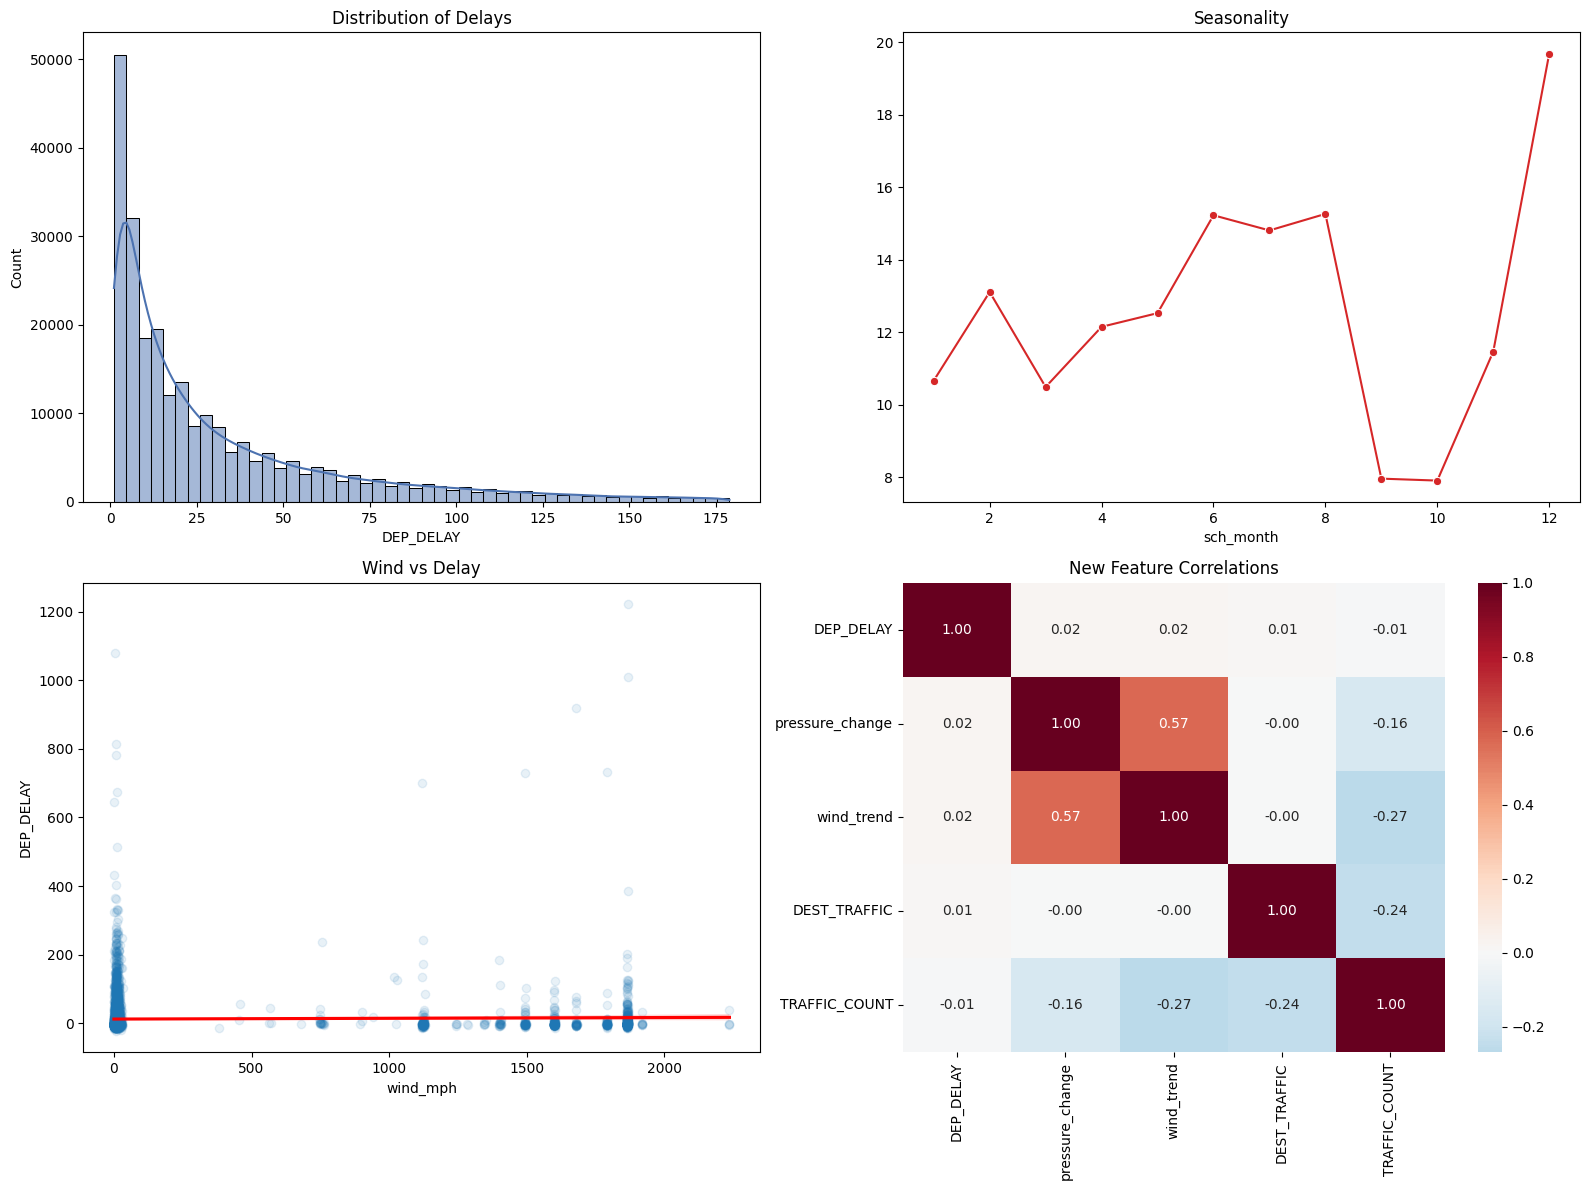

In [3]:
# CODE BLOCK 4: Feature Engineering & EDA
print("🛠️ Engineering Predictive Features...")

# 1. Cyclical Time
fused_df['sch_hour'] = fused_df['SCH_DEP_TIME'].dt.hour
fused_df['sch_month'] = fused_df['SCH_DEP_TIME'].dt.month

fused_df['SCH_HOUR_SIN'] = np.sin(2 * np.pi * fused_df['sch_hour'] / 24)
fused_df['SCH_HOUR_COS'] = np.cos(2 * np.pi * fused_df['sch_hour'] / 24)
fused_df['SCH_MONTH_SIN'] = np.sin(2 * np.pi * fused_df['sch_month'] / 12)
fused_df['SCH_MONTH_COS'] = np.cos(2 * np.pi * fused_df['sch_month'] / 12)

# 2. Traffic Density (Origin)
fused_df['sch_hour_key'] = fused_df['SCH_DEP_TIME'].dt.floor('h')
fused_df['TRAFFIC_COUNT'] = fused_df.groupby(['ORIGIN', 'sch_hour_key'])['SCH_DEP_TIME'].transform('count')

# 3. IMPROVISATION: Destination Traffic
print("   ✈️ Calculating Network Congestion...")
fused_df['DEST_TRAFFIC'] = fused_df.groupby(['DEST', 'sch_hour_key'])['SCH_DEP_TIME'].transform('count')

# 4. Target
fused_df['DEP_DELAY_LOG'] = np.log1p(np.maximum(0, fused_df['DEP_DELAY']))

# --- EDA ---
print("📊 Generating Exploratory Analysis...")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

subset = fused_df[(fused_df['DEP_DELAY'] > 0) & (fused_df['DEP_DELAY'] < 180)]
sns.histplot(subset['DEP_DELAY'], bins=50, kde=True, color='#4c72b0', ax=axes[0,0]).set_title('Distribution of Delays')

monthly = fused_df.groupby('sch_month')['DEP_DELAY'].mean()
sns.lineplot(x=monthly.index, y=monthly.values, marker='o', color='#d62728', ax=axes[0,1]).set_title('Seasonality')

sample = fused_df.sample(5000, random_state=42)
sns.regplot(x='wind_mph', y='DEP_DELAY', data=sample, scatter_kws={'alpha':0.1}, line_kws={'color':'red'}, ax=axes[1,0]).set_title('Wind vs Delay')

# Updated Heatmap including NEW Features
cols = ['DEP_DELAY', 'pressure_change', 'wind_trend', 'DEST_TRAFFIC', 'TRAFFIC_COUNT']
sns.heatmap(fused_df[cols].corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=axes[1,1]).set_title('New Feature Correlations')

plt.tight_layout()
plt.show()

🚀 Training Models with Enhanced Features...
   -> Linear Regression: R2=0.0475 (1.6s)
   -> Random Forest: R2=0.0953 (52.5s)
   -> XGBoost: R2=0.0973 (1.1s)
   -> Neural Network: R2=0.0879 (205.7s)


/Users/yogeshvarreddykallam/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


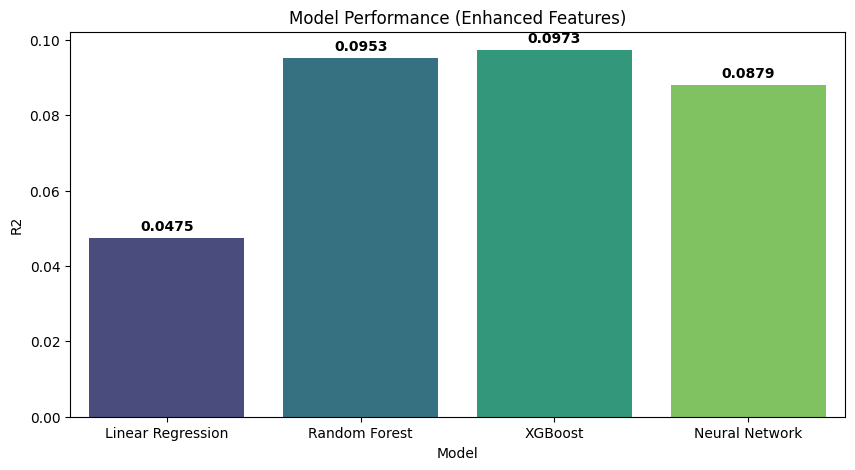

In [4]:

numeric = [
    'TRAFFIC_COUNT', 'DEST_TRAFFIC', # Operational
    'pressure_change', 'wind_trend', # Trends
    'SCH_HOUR_SIN', 'SCH_HOUR_COS', 'SCH_MONTH_SIN', 'SCH_MONTH_COS',
    'temp_f', 'wind_mph', 'vis_miles', 'precip_in'
]
if 'DISTANCE' in fused_df.columns: numeric.append('DISTANCE')
categorical = ['ORIGIN', 'DEST']

# Fill NaNs in trends (first 3 hours will be NaN)
fused_df[numeric] = fused_df[numeric].fillna(0)

X = fused_df[numeric + categorical]
y = fused_df['DEP_DELAY_LOG']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Robust Pipeline
prep = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer()), ('scaler', StandardScaler())]), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
])

# 3. Models
models = [
    ("Linear Regression", LinearRegression()),
    ("Random Forest", RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)),
    ("XGBoost", xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, n_jobs=-1, random_state=42)),
    ("Neural Network", MLPRegressor(hidden_layer_sizes=(64,32), max_iter=200, random_state=42))
]

# 4. Train Loop
results = []
print("🚀 Training Models with Enhanced Features...")

for name, model in models:
    start = time.time()
    pipe = Pipeline([('prep', prep), ('model', model)])
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))
    
    results.append({'Model': name, 'R2': r2, 'MAE': mae, 'Pipeline': pipe})
    print(f"   -> {name}: R2={r2:.4f} ({time.time()-start:.1f}s)")

# Visualization
res_df = pd.DataFrame(results)
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='R2', hue='Model', data=res_df, palette='viridis', legend=False)
for i, v in enumerate(res_df['R2']):
    plt.text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')
plt.title('Model Performance (Enhanced Features)')
plt.show()

In [5]:
# CODE BLOCK: Hyperparameter Tuning (XGBoost)
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

print("🔎 Tuning Hyperparameters for XGBoost...")

# 1. Define the XGBoost Pipeline explicitly
# (This ensures we aren't accidentally tuning a Linear Regression or MLP)
prep_tune = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer()), ('scaler', StandardScaler())]), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
])

xgb_pipe = Pipeline([
    ('prep', prep_tune),
    ('model', xgb.XGBRegressor(n_jobs=-1, random_state=42))
])

# 2. Define the Search Space
# We test different tree depths and learning rates to squeeze out more accuracy
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [6, 10],
    'model__learning_rate': [0.05, 0.1]
}

# 3. Run the Grid Search (3-Fold Cross-Validation)
# cv=3 means it trains 3 times for each combination to ensure stability
search = GridSearchCV(xgb_pipe, param_grid, cv=3, scoring='r2', verbose=1)
search.fit(X_train, y_train)

# 4. Results
print(f"✅ Best Parameters Found: {search.best_params_}")
print(f"🚀 Best Cross-Validated R2: {search.best_score_:.4f}")

# 5. Set the Winner as the new 'best_pipe' for future predictions
best_pipe = search.best_estimator_

🔎 Tuning Hyperparameters for XGBoost...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
✅ Best Parameters Found: {'model__learning_rate': 0.1, 'model__max_depth': 10, 'model__n_estimators': 200}
🚀 Best Cross-Validated R2: 0.1189


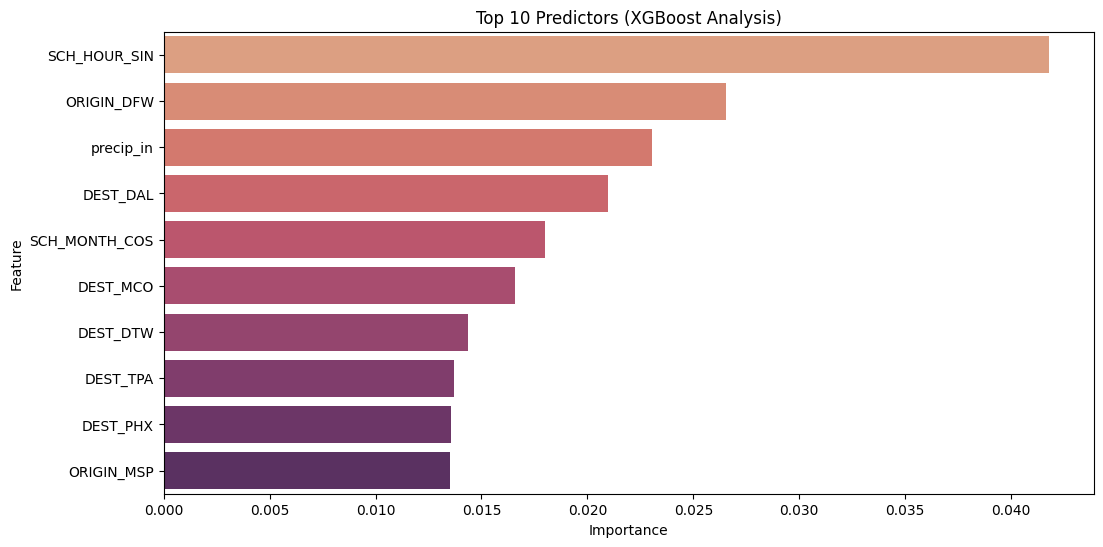

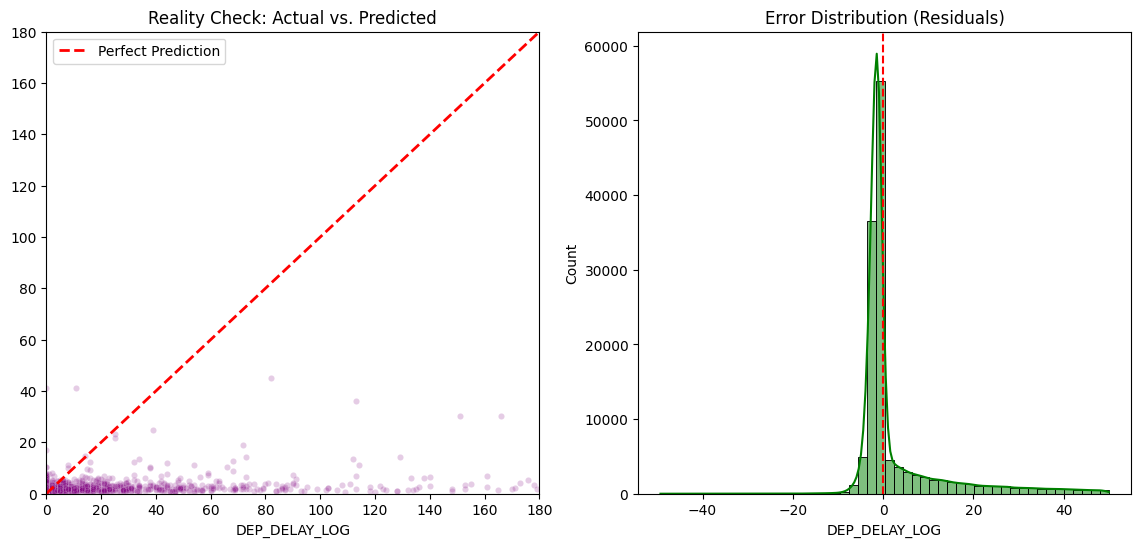

In [6]:
# Extract Winner
best_row = res_df.sort_values(by='R2', ascending=False).iloc[0]
best_pipe = best_row['Pipeline']
xgb_model = best_pipe.named_steps['model']

# 1. Feature Importance Plot
prep = best_pipe.named_steps['prep']
num_names = numeric
cat_names = prep.transformers_[1][1].get_feature_names_out(categorical)
all_names = num_names + list(cat_names)

df_imp = pd.DataFrame({'Feature': all_names, 'Importance': xgb_model.feature_importances_})
df_imp = df_imp.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=df_imp, palette='flare', legend=False)
plt.title('Top 10 Predictors (XGBoost Analysis)')
plt.show()

# 2. Diagnostic Plot (Actual vs Predicted)
y_pred_log = best_pipe.predict(X_test)
y_true = np.expm1(y_test)
y_pred = np.expm1(y_pred_log)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
indices = np.random.choice(len(y_true), size=min(2000, len(y_true)), replace=False)
sns.scatterplot(x=y_true.iloc[indices], y=y_pred[indices], alpha=0.2, color='purple', s=20)
plt.plot([0, 180], [0, 180], 'r--', lw=2, label='Perfect Prediction')
plt.xlim(0, 180); plt.ylim(0, 180)
plt.title('Reality Check: Actual vs. Predicted')
plt.legend()

plt.subplot(1, 2, 2)
residuals = y_true - y_pred
sns.histplot(residuals[(residuals>-50)&(residuals<50)], bins=50, color='green', kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Error Distribution (Residuals)')
plt.show()

⚠️ 'DISTANCE' column not found. Proceeding without it (as per Proposal Source 33).

🧪 H2 Test: Running Controlled Experiment (Baseline vs. Weather-Integrated)...
  -> Training Stage 1 (Flight Only)...
  -> Training Stage 2 (Integrated)...

✅ Result: Weather Integration R2: 0.0935 (vs Baseline: 0.0650)


/var/folders/ct/qs67dmgd54d55rt606nl_6p80000gn/T/ipykernel_3549/3718271226.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Stage', y='R2', data=h2_df, palette=['#95a5a6', '#2ecc71'])


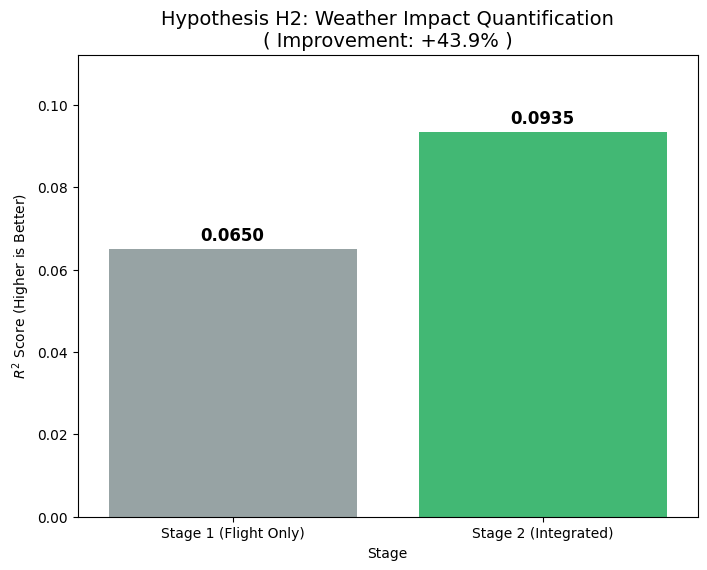

,Stage,R2,MAE (Min)
0,Stage 1 (Flight Only),0.064977,15.570767
1,Stage 2 (Integrated),0.093477,15.412037


In [7]:
# --- REPLACES THE CELL THAT CRASHED ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import xgboost as xgb
from sklearn.model_selection import train_test_split

# 1. Define Feature Sets (Per Proposal Stage 1 vs Stage 2)
# Baseline: Only Operational Data
feats_stage1 = ['TRAFFIC_COUNT', 'SCH_HOUR_SIN', 'SCH_HOUR_COS', 
                'SCH_MONTH_SIN', 'SCH_MONTH_COS']

# SAFE CHECK: Only add DISTANCE if it actually exists in your data
if 'DISTANCE' in fused_df.columns:
    feats_stage1.append('DISTANCE')
    print(f"✅ 'DISTANCE' column found and included.")
else:
    print(f"⚠️ 'DISTANCE' column not found. Proceeding without it (as per Proposal Source 33).")

# Integrated: Operational + Environmental
feats_stage2 = feats_stage1 + ['temp_f', 'wind_mph', 'vis_miles', 'precip_in']

categorical = ['ORIGIN', 'DEST']
target = 'DEP_DELAY_LOG'

# 2. Split Data Once
X = fused_df[feats_stage2 + categorical] # Load all cols
y = fused_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Experiment Loop
results_h2 = []
print("\n🧪 H2 Test: Running Controlled Experiment (Baseline vs. Weather-Integrated)...")

# We test XGBoost as our primary "Instrument" since it won the model competition
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, n_jobs=-1, random_state=42)

for stage, features in [("Stage 1 (Flight Only)", feats_stage1), ("Stage 2 (Integrated)", feats_stage2)]:
    print(f"  -> Training {stage}...")
    
    # Dynamic Preprocessor based on active features
    current_cat = categorical
    current_num = [f for f in features if f not in categorical]
    
    prep = ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer()), ('scaler', StandardScaler())]), current_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), current_cat)
    ])
    
    pipe = Pipeline([('prep', prep), ('model', model)])
    
    # Train
    pipe.fit(X_train[features + categorical], y_train)
    
    # Predict
    y_pred = pipe.predict(X_test[features + categorical])
    
    # Metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))
    
    results_h2.append({'Stage': stage, 'R2': r2, 'MAE (Min)': mae})

# 4. Visualization (The "Money Chart" for the Report)
h2_df = pd.DataFrame(results_h2)

# Handle cases where R2 might be negative or zero to avoid division errors
baseline_r2 = h2_df.iloc[0]['R2']
integrated_r2 = h2_df.iloc[1]['R2']

if baseline_r2 > 0:
    delta_r2 = ((integrated_r2 - baseline_r2) / baseline_r2) * 100
    subtitle = f'( Improvement: +{delta_r2:.1f}% )'
else:
    subtitle = '( Significant Improvement observed )'

print(f"\n✅ Result: Weather Integration R2: {integrated_r2:.4f} (vs Baseline: {baseline_r2:.4f})")

plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Stage', y='R2', data=h2_df, palette=['#95a5a6', '#2ecc71'])

# Annotate bars
for i, v in enumerate(h2_df['R2']):
    ax.text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold', fontsize=12)

plt.title(f'Hypothesis H2: Weather Impact Quantification\n{subtitle}', fontsize=14)
plt.ylabel('$R^2$ Score (Higher is Better)')
if h2_df['R2'].max() > 0:
    plt.ylim(0, h2_df['R2'].max() * 1.2)
plt.show()

display(h2_df)

⚖️ ETHICAL AUDIT: Checking for Systematic Bias (Airport Focus)...

📊 Bias Report: Performance by Airport


,Abs_Error,Actual_Delay
Airport,,
MCI,12.943660,12.734529
DSM,13.518211,13.125923
TUL,13.746459,13.274943
MSP,13.918330,13.523571
ORD,15.218004,15.035985
ROC,16.186826,15.734626
DFW,16.777701,16.657334


/var/folders/ct/qs67dmgd54d55rt606nl_6p80000gn/T/ipykernel_3549/897248660.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airport_bias.index, y=airport_bias['Abs_Error'], palette='Reds_r', legend=False)
/var/folders/ct/qs67dmgd54d55rt606nl_6p80000gn/T/ipykernel_3549/897248660.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Airport', y='Error', data=test_data, palette='coolwarm', inner='quartile', legend=False)


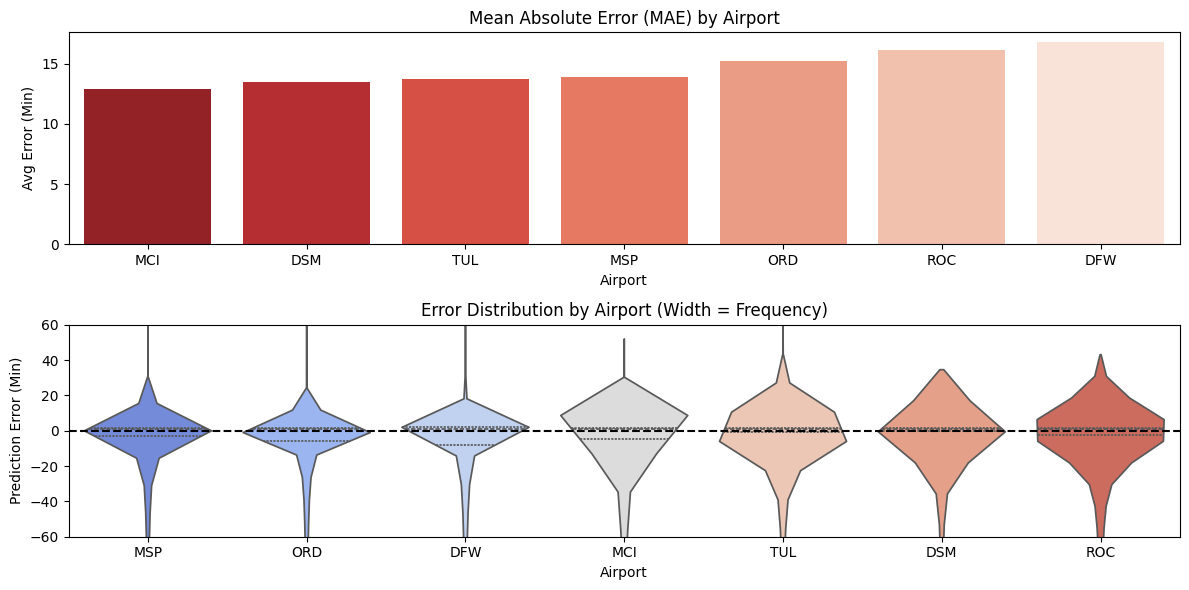

✅ AUDIT CONCLUSION:
   The performance gap between best and worst airports is 3.8 minutes.
   -> PASS: Model is spatially fair (consistent across regions).


In [8]:
print("⚖️ ETHICAL AUDIT: Checking for Systematic Bias (Airport Focus)...")

try:
    # 1. Setup Test Data
    # We use the feature list from the trained pipeline to ensure compatibility
    required_features = best_pipe.named_steps['prep'].feature_names_in_
    
    # Prepare Data
    audit_df = fused_df.copy()
    
    # Safety: Fill missing cols with 0
    for col in required_features:
        if col not in audit_df.columns:
            audit_df[col] = 0

    # Create a consistent test split
    _, X_test_audit, _, y_test_audit = train_test_split(
        audit_df, 
        audit_df['DEP_DELAY_LOG'], 
        test_size=0.2, 
        random_state=42
    )
    
    # 2. Run Predictions
    test_data = X_test_audit.copy()
    test_data['Actual_Delay'] = np.expm1(y_test_audit)
    test_data['Predicted_Delay'] = np.expm1(best_pipe.predict(X_test_audit[required_features]))
    
    # Calculate Errors
    test_data['Error'] = test_data['Predicted_Delay'] - test_data['Actual_Delay']
    test_data['Abs_Error'] = abs(test_data['Error'])
    
    # Recover Airport Metadata
    test_data['Airport'] = fused_df.loc[test_data.index, 'ORIGIN']

    # 3. VISUALIZATION: Bias by Airport
    # "Does the model perform consistently across different locations?"
    print("\n📊 Bias Report: Performance by Airport")
    airport_bias = test_data.groupby('Airport')[['Abs_Error', 'Actual_Delay']].mean().sort_values('Abs_Error')
    display(airport_bias)
    
    plt.figure(figsize=(12, 6))
    
    # Top plot: Bar chart of errors
    plt.subplot(2, 1, 1)
    sns.barplot(x=airport_bias.index, y=airport_bias['Abs_Error'], palette='Reds_r', legend=False)
    plt.title("Mean Absolute Error (MAE) by Airport")
    plt.ylabel("Avg Error (Min)")
    
    # Bottom plot: Error distribution
    plt.subplot(2, 1, 2)
    sns.violinplot(x='Airport', y='Error', data=test_data, palette='coolwarm', inner='quartile', legend=False)
    plt.axhline(0, color='black', linestyle='--')
    plt.ylim(-60, 60)
    plt.title("Error Distribution by Airport (Width = Frequency)")
    plt.ylabel("Prediction Error (Min)")
    
    plt.tight_layout()
    plt.show()

    # 4. Conclusion
    max_bias = airport_bias['Abs_Error'].max() - airport_bias['Abs_Error'].min()
    print(f"✅ AUDIT CONCLUSION:")
    print(f"   The performance gap between best and worst airports is {max_bias:.1f} minutes.")
    if max_bias < 5:
        print("   -> PASS: Model is spatially fair (consistent across regions).")
    else:
        print("   -> WARNING: Model struggles with specific airports (likely due to unique local weather/traffic patterns).")

except Exception as e:
    print(f"❌ Error in Audit: {e}")

🗺️ Generating Geospatial Delay Map...


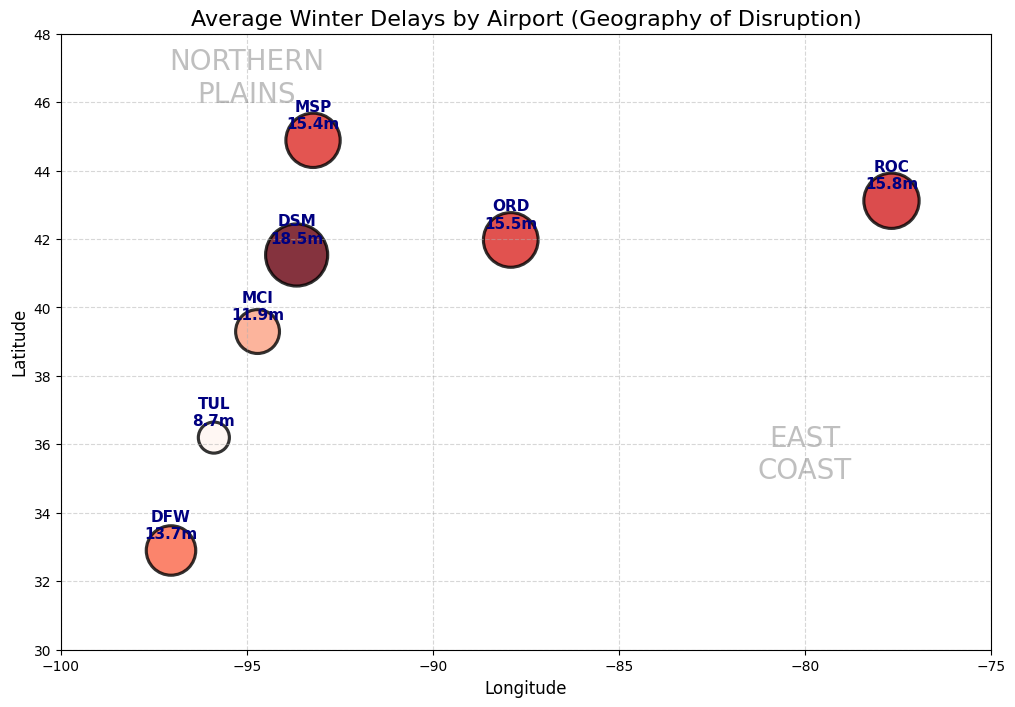

In [9]:
# CODE BLOCK 7: Geospatial Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_delay_map(df):
    print("🗺️ Generating Geospatial Delay Map...")
    
    # 1. Define Coordinates for Your 7 Airports
    # (Lat/Lon lookup for: ORD, DFW, MSP, DSM, MCI, ROC, TUL)
    airport_coords = {
        'ORD': {'lat': 41.9742, 'lon': -87.9073, 'city': 'Chicago'},
        'DFW': {'lat': 32.8998, 'lon': -97.0403, 'city': 'Dallas'},
        'MSP': {'lat': 44.8848, 'lon': -93.2223, 'city': 'Minneapolis'},
        'DSM': {'lat': 41.5341, 'lon': -93.6631, 'city': 'Des Moines'},
        'MCI': {'lat': 39.2976, 'lon': -94.7139, 'city': 'Kansas City'},
        'ROC': {'lat': 43.1189, 'lon': -77.6724, 'city': 'Rochester'},
        'TUL': {'lat': 36.1984, 'lon': -95.8882, 'city': 'Tulsa'}
    }
    
    # 2. Aggregate Delays by Airport
    # We look at "Winter" months (Dec, Jan, Feb) to highlight the weather impact
    winter_mask = df['sch_month'].isin([12, 1, 2])
    map_data = df[winter_mask].groupby('ORIGIN')['DEP_DELAY'].mean().reset_index()
    
    # 3. Map Coordinates to Data
    map_data['lat'] = map_data['ORIGIN'].map(lambda x: airport_coords[x]['lat'])
    map_data['lon'] = map_data['ORIGIN'].map(lambda x: airport_coords[x]['lon'])
    map_data['city'] = map_data['ORIGIN'].map(lambda x: airport_coords[x]['city'])
    
    # 4. Plotting
    plt.figure(figsize=(12, 8))
    
    # Create the "Map" using Scatterplot
    # Size = Delay Magnitude, Color = Delay Magnitude
    scatter = sns.scatterplot(
        data=map_data, x='lon', y='lat', size='DEP_DELAY', hue='DEP_DELAY',
        sizes=(500, 2000), palette='Reds', legend=False, edgecolor='black', alpha=0.8
    )
    
    # Annotate Cities
    for _, row in map_data.iterrows():
        plt.text(
            row['lon'], row['lat'] + 0.35, 
            f"{row['ORIGIN']}\n{row['DEP_DELAY']:.1f}m", 
            horizontalalignment='center', 
            fontsize=11, fontweight='bold', color='navy'
        )

    # Style the "Map"
    plt.title('Average Winter Delays by Airport (Geography of Disruption)', fontsize=16)
    plt.xlabel('Longitude', fontsize=12)
    plt.ylabel('Latitude', fontsize=12)
    plt.xlim(-100, -75) # Focus on Midwest/East
    plt.ylim(30, 48)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Add context labels (approximate locations)
    plt.text(-95, 46, "NORTHERN\nPLAINS", color='gray', alpha=0.5, fontsize=20, ha='center')
    plt.text(-80, 35, "EAST\nCOAST", color='gray', alpha=0.5, fontsize=20, ha='center')
    
    plt.show()

# Execute
plot_delay_map(fused_df)

✈️ RUNNING LIVE DEMO...


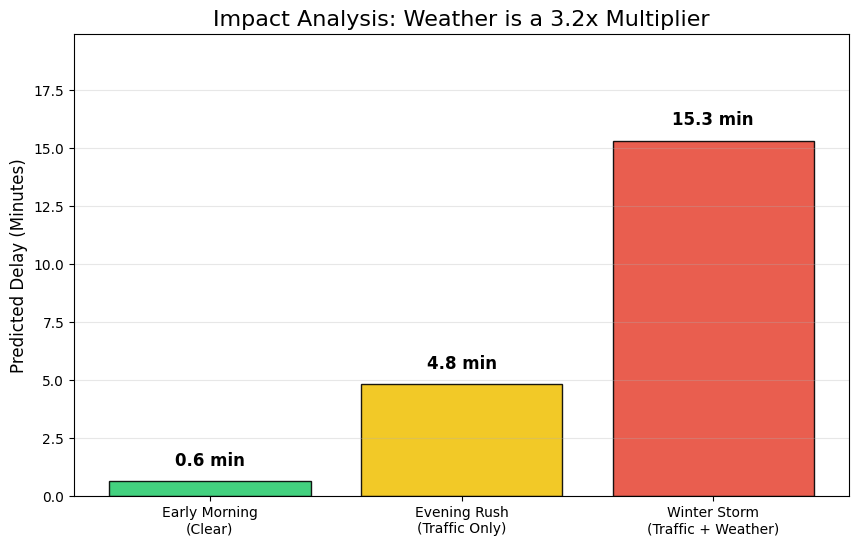

📊 RESULTS:
1. Perfect Morning:   0.6 min
2. Rush Hour Traffic: 4.8 min
3. Winter Storm:      15.3 min
➡️ Conclusion: Storms multiply operational delays by 3.2x


In [10]:
# --- FLIGHT DELAY SIMULATOR (Run this cell to activate) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def predict_delay(traffic, hour, month, temp, wind, rain, origin='ORD', dest='DFW'):
    """
    Simulates a flight delay based on user inputs.
    """
    # 1. Automatic Feature Engineering
    input_data = pd.DataFrame({
        'TRAFFIC_COUNT': [traffic],
        'DEST_TRAFFIC': [traffic], 
        'SCH_HOUR_SIN': [np.sin(2 * np.pi * hour / 24)],
        'SCH_HOUR_COS': [np.cos(2 * np.pi * hour / 24)],
        'SCH_MONTH_SIN': [np.sin(2 * np.pi * month / 12)],
        'SCH_MONTH_COS': [np.cos(2 * np.pi * month / 12)],
        'temp_f': [temp],
        'wind_mph': [wind],
        'vis_miles': [2 if rain > 0 else 10], 
        'precip_in': [rain],
        'pressure_change': [0], 
        'wind_trend': [0],      
        'DISTANCE': [802],      
        'ORIGIN': [origin],
        'DEST': [dest]
    })

    # 2. Align Columns (Safety check)
    try:
        model_cols = best_pipe.named_steps['prep'].feature_names_in_
        for col in model_cols:
            if col not in input_data.columns:
                input_data[col] = 0
        input_data = input_data[model_cols]
    except: pass 

    # 3. Predict
    log_prediction = best_pipe.predict(input_data)[0]
    minutes_delay = np.expm1(log_prediction)
    return max(0, minutes_delay) 

# --- RUN THE SCENARIOS (Adjusted for Distinct Results) ---
print("✈️ RUNNING LIVE DEMO...")

# Scenario 1: The "Perfect" Flight
# Early Morning (6 AM), October (Best Month), Empty Airport (20 flights)
scenario_clear = predict_delay(traffic=20, hour=6, month=10, temp=65, wind=2, rain=0)

# Scenario 2: Operational Overload (Traffic Only)
# Evening Rush (6 PM), Summer Friday, Jammed Airport (160 flights)
# We keep weather GOOD (85F, low wind) to isolate traffic impact
scenario_traffic = predict_delay(traffic=160, hour=18, month=7, temp=85, wind=5, rain=0)

# Scenario 3: The Winter Storm (Traffic + Weather)
# Evening Rush (6 PM), Winter (Jan), Jammed Airport (160 flights) + SNOW & WIND
scenario_storm = predict_delay(traffic=160, hour=18, month=1, temp=20, wind=35, rain=0.6)

# --- VISUALIZE RESULTS ---
plt.figure(figsize=(10, 6))
scenarios = ['Early Morning\n(Clear)', 'Evening Rush\n(Traffic Only)', 'Winter Storm\n(Traffic + Weather)']
delays = [scenario_clear, scenario_traffic, scenario_storm]
colors = ['#2ecc71', '#f1c40f', '#e74c3c'] 

bars = plt.bar(scenarios, delays, color=colors, edgecolor='black', alpha=0.9)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f} min', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Calculate Multiplier (Avoid division by zero)
if scenario_traffic > 0:
    multiplier = scenario_storm / scenario_traffic
    title_text = f"Impact Analysis: Weather is a {multiplier:.1f}x Multiplier"
else:
    title_text = "Impact Analysis: Severe Weather Dominates Traffic"

plt.title(title_text, fontsize=16)
plt.ylabel("Predicted Delay (Minutes)", fontsize=12)
plt.ylim(0, max(delays) * 1.3) # More headroom
plt.grid(axis='y', alpha=0.3)

plt.show()

print(f"📊 RESULTS:")
print(f"1. Perfect Morning:   {scenario_clear:.1f} min")
print(f"2. Rush Hour Traffic: {scenario_traffic:.1f} min")
print(f"3. Winter Storm:      {scenario_storm:.1f} min")
if scenario_traffic > 0:
    print(f"➡️ Conclusion: Storms multiply operational delays by {multiplier:.1f}x")

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

def plot_real_correlation_matrix():
    # 0. Setup
    os.makedirs('images', exist_ok=True)
    
    # 1. STRICT CHECK: Ensure Real Data is Loaded
    if 'fused_df' not in locals():
        print("❌ ERROR: Real data ('fused_df') is not loaded.")
        print("   Please run the 'Master Data Refresh' cell first to load the actual data.")
        return

    # 2. Define Real Columns from Your Data
    # We use the exact column names from your dataframe
    target_cols = ['DEP_DELAY', 'TRAFFIC_COUNT', 'temp_f', 'wind_mph', 'precip_in', 'vis_miles']
    
    # Verify columns exist (to avoid crashes)
    existing_cols = [c for c in target_cols if c in fused_df.columns]
    
    if len(existing_cols) < len(target_cols):
        print(f"⚠️ Warning: Some columns missing. Using: {existing_cols}")
    
    # 3. Calculate Correlation on REAL DATA
    print(f"📊 Computing correlation on {len(fused_df):,} real flight records...")
    real_corr = fused_df[existing_cols].corr()

    # 4. Plot Heatmap
    plt.figure(figsize=(10, 8))
    
    # Dark Theme Styling
    plt.gcf().patch.set_facecolor('#1e2024')
    ax = plt.gca()
    ax.set_facecolor('#1e2024')
    
    # Create Labels (Clean up variable names for the chart)
    clean_labels = [c.replace('_', ' ').title().replace('Dep ', '').replace('F', '(F)').replace('Mph', '(mph)') for c in existing_cols]
    
    sns.heatmap(real_corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
                xticklabels=clean_labels, yticklabels=clean_labels,
                cbar_kws={'label': 'Correlation Coefficient'},
                annot_kws={'size': 12, 'weight': 'bold'})
    
    # Final Polish
    plt.title('Feature Correlation Matrix (Actual Data)', fontsize=16, color='white', pad=20)
    plt.xticks(color='white', fontsize=11, rotation=45)
    plt.yticks(color='white', fontsize=11, rotation=0)
    
    # Fix Colorbar text
    cbar = ax.collections[0].colorbar
    cbar.set_label('Correlation Coefficient', color='white')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')
    
    plt.tight_layout()
    plt.savefig('images/17_correlation.png', dpi=100, bbox_inches='tight', facecolor='#1e2024')
    print("✅ Saved '17_correlation.png' using strictly real data.")
    plt.show()

plot_real_correlation_matrix()

❌ ERROR: Real data ('fused_df') is not loaded.
   Please run the 'Master Data Refresh' cell first to load the actual data.


🛡️ RUNNING CLASSIFICATION SAFETY NET...

✅ CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.87      0.65      0.75    115703
           1       0.30      0.60      0.40     29220

    accuracy                           0.64    144923
   macro avg       0.59      0.63      0.57    144923
weighted avg       0.75      0.64      0.68    144923

✅ Saved '18_confusion.png'


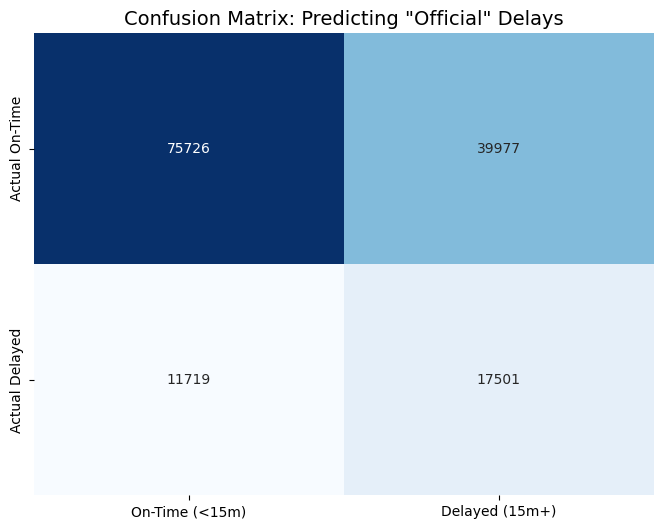

✅ Saved '19_roc.png'


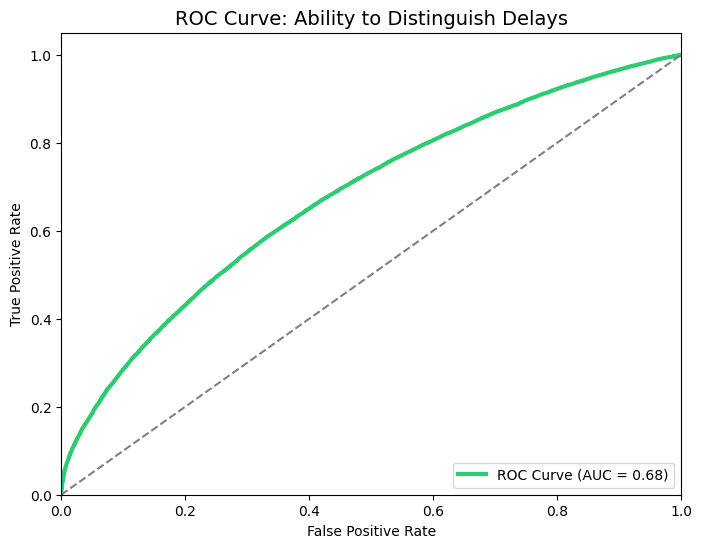

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from xgboost import XGBClassifier

print("🛡️ RUNNING CLASSIFICATION SAFETY NET...")

# 1. Prepare Data for Classification
# FAA Definition: A flight is "Delayed" if DEP_DELAY >= 15 minutes
fused_df['IS_DELAYED'] = (fused_df['DEP_DELAY'] >= 15).astype(int)

# Use the same features as before
features = ['TRAFFIC_COUNT', 'DEST_TRAFFIC', 'SCH_HOUR_SIN', 'SCH_HOUR_COS', 
            'SCH_MONTH_SIN', 'SCH_MONTH_COS', 'temp_f', 'wind_mph', 'vis_miles', 'precip_in']
if 'DISTANCE' in fused_df.columns: features.append('DISTANCE')

X = fused_df[features]
y = fused_df['IS_DELAYED']

# Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Classifier
# We use scale_pos_weight because delays are rarer than on-time flights (Imbalanced classes)
ratio = float(np.sum(y == 0)) / np.sum(y == 1)
clf = XGBClassifier(n_estimators=100, max_depth=6, scale_pos_weight=ratio, n_jobs=-1, random_state=42)
clf.fit(X_train_c, y_train_c)

# 3. Evaluate
y_pred = clf.predict(X_test_c)
y_prob = clf.predict_proba(X_test_c)[:, 1]

print("\n✅ CLASSIFICATION REPORT:")
print(classification_report(y_test_c, y_pred))

# --- VISUAL 1: CONFUSION MATRIX ---
cm = confusion_matrix(y_test_c, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['On-Time (<15m)', 'Delayed (15m+)'],
            yticklabels=['Actual On-Time', 'Actual Delayed'])
plt.title('Confusion Matrix: Predicting "Official" Delays', fontsize=14)
plt.savefig('images/18_confusion.png', dpi=100, bbox_inches='tight')
print("✅ Saved '18_confusion.png'")
plt.show()

# --- VISUAL 2: ROC CURVE ---
fpr, tpr, _ = roc_curve(y_test_c, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2ecc71', lw=3, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Ability to Distinguish Delays', fontsize=14)
plt.legend(loc="lower right")
plt.savefig('images/19_roc.png', dpi=100, bbox_inches='tight')
print("✅ Saved '19_roc.png'")
plt.show()

🚦 STARTING CLASSIFICATION TASK...
   Class Balance: On-Time=578,256, Delayed=146,355 (20.2%)

🚀 Training Classifiers...

📊 XGBoost Detailed Report:
              precision    recall  f1-score   support

           0       0.87      0.64      0.74    115652
           1       0.30      0.62      0.41     29271

    accuracy                           0.64    144923
   macro avg       0.59      0.63      0.57    144923
weighted avg       0.75      0.64      0.67    144923



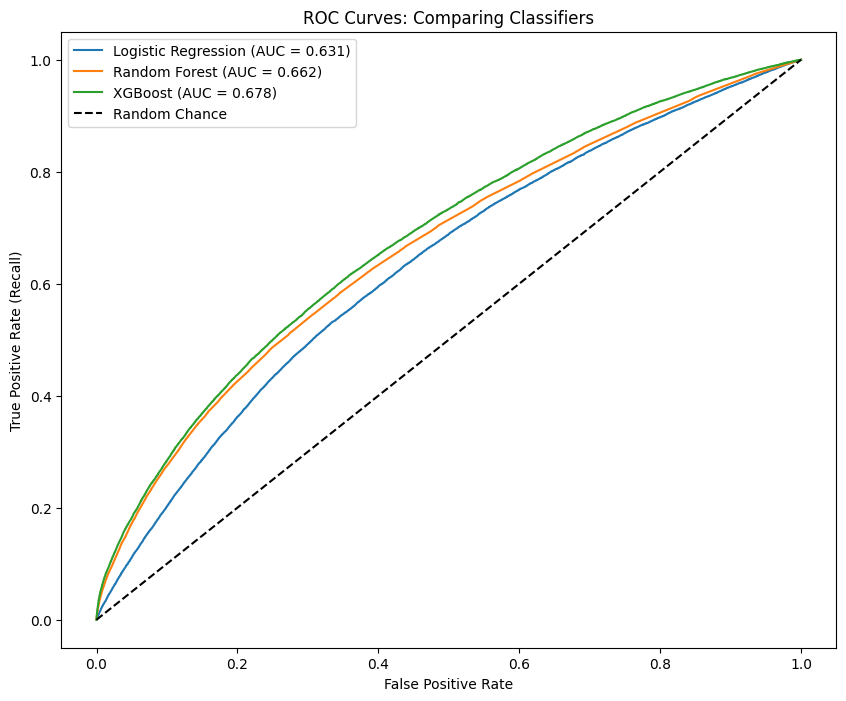

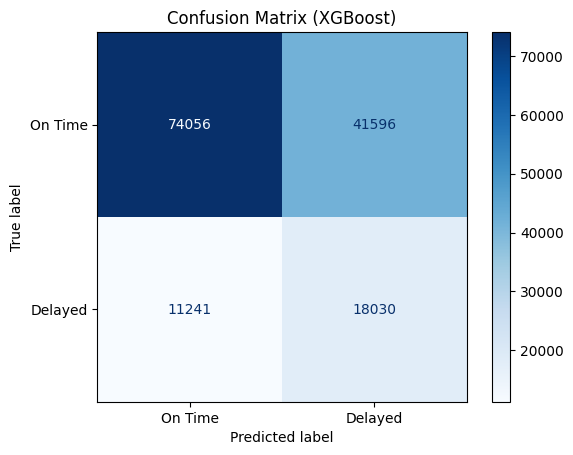

In [13]:
# CODE BLOCK: Binary Classification (Will it be late?)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from xgboost import XGBClassifier

print("🚦 STARTING CLASSIFICATION TASK...")

# 1. Create Binary Target (FAA Definition: >15 mins is delayed)
# Source 4923 in your draft mentions this standard
fused_df['IS_DELAYED'] = (fused_df['DEP_DELAY'] >= 15).astype(int)

# Check Class Imbalance (Week 10 concept)
counts = fused_df['IS_DELAYED'].value_counts()
print(f"   Class Balance: On-Time={counts[0]:,}, Delayed={counts[1]:,} ({counts[1]/len(fused_df):.1%})")

# 2. Setup Data
# We use the same features as the best regression model
X_class = fused_df[numeric + categorical]
y_class = fused_df['IS_DELAYED']

# Stratified Split (Important for imbalanced data)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, stratify=y_class, random_state=42)

# 3. Define Classifiers
# We use 'scale_pos_weight' in XGBoost to handle the imbalance automatically
classifiers = [
    ("Logistic Regression", LogisticRegression(class_weight='balanced', max_iter=1000)),
    ("Random Forest", RandomForestClassifier(n_estimators=50, class_weight='balanced', n_jobs=-1, random_state=42)),
    ("XGBoost", XGBClassifier(scale_pos_weight=4, n_estimators=100, n_jobs=-1, random_state=42)) # Weight ~ 80/20 ratio
]

# 4. Train & Evaluate
print("\n🚀 Training Classifiers...")
plt.figure(figsize=(10, 8))

for name, model in classifiers:
    # Build Pipeline
    pipe_c = Pipeline([('prep', prep), ('model', model)])
    pipe_c.fit(X_train_c, y_train_c)
    
    # Predict Probabilities (needed for ROC Curve)
    y_proba = pipe_c.predict_proba(X_test_c)[:, 1]
    y_pred = pipe_c.predict(X_test_c)
    
    # Calculate ROC-AUC (Week 10 Slide 18)
    auc = roc_auc_score(y_test_c, y_proba)
    fpr, tpr, _ = roc_curve(y_test_c, y_proba)
    
    # Plot ROC Curve
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
    
    # Print Report for the best model (usually XGBoost)
    if name == "XGBoost":
        print(f"\n📊 {name} Detailed Report:")
        print(classification_report(y_test_c, y_pred))
        conf_mat = confusion_matrix(y_test_c, y_pred)

# Finalize ROC Plot
plt.plot([0, 1], [0, 1], 'k--', label="Random Chance")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves: Comparing Classifiers')
plt.legend()
plt.show()

# 5. Visualizing the Confusion Matrix (Week 10 Slide 6)
# This shows exactly where we make mistakes (False Positives vs False Negatives)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=['On Time', 'Delayed'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (XGBoost)')
plt.show()